In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

import numpy as np

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

2026-01-09 05:24:39.883185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767932679.901712  952097 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767932679.907435  952097 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767932679.921330  952097 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767932679.921347  952097 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767932679.921349  952097 computation_placer.cc:177] computation placer alr

In [2]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/das214/SmartPix/SoftQuantize')
!pwd

/home/das214/SmartPix/SoftQuantize


In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [4]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"
# dataset_base_dir = '/depot/cms/users/das214/datasets/temporary/preamp_response/'
print(os.listdir(dataset_base_dir))

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t_N_0.0mu_80.0sig_NoLog_Stdr")
print(os.listdir(os.path.join(dataset_base_dir, "TFR_files")))
print(os.listdir(tfrecords_base_dir))

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

['train', 'test', 'TFR_files']
['2t_N_0.0mu_80.0sig_NoLog_Stdr', '2t_N_0.0mu_80.0sig', '2t_N_0.0mu_400.0sig', 'TRanf2_2t_N_0.0mu_80.0sig']
['TFR_val', 'TFR_train']


In [5]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)

print("num train batches:", len(training_generator))
print("num val batches  :", len(validation_generator))

b = 0
X, y = training_generator[b]
X = X.numpy()
y = y.numpy()

print("X shape:", X.shape, "dtype:", X.dtype)   # expect (B, H, W, C) or similar
print("y shape:", y.shape, "dtype:", y.dtype)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json


Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json


num train batches: 84
num val batches  : 21
X shape: (5000, 16, 16, 2) dtype: float32
y shape: (5000, 4) dtype: float32


I0000 00:00:1767932685.344819  952097 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38397 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 7g.40gb, pci bus id: 0000:21:00.0, compute capability: 8.0
2026-01-09 05:24:45.638871: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


In [6]:
# Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
# Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
# Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16

In [7]:
def create_quantizer_model(input_shape, initial_thresholds, threshold_offset):
    inp = layers.Input(shape=input_shape, name="raw_input")
    q_out = SoftQuantizeLayer(
        n_bits=2,
        initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
        threshold_offset=threshold_offset,
        initial_thresholds=initial_thresholds,
        trainable_levels=False,
        trainable_thresholds=False,
        initial_k=50.0,
        trainable_k=True,
        name="soft_quantizer_output"
    )(inp)
    return keras.Model(inputs=inp, outputs=q_out, name="quantizer")

quantizer_model = create_quantizer_model(
    input_shape=(16,16,2),
    initial_thresholds=[249.30, 667.66, 1659.27],
    threshold_offset=80.0
)

In [8]:
b = 0
X, y = training_generator[b]

print("X shape:", X.shape, "dtype:", X.dtype) 
print("y shape:", y.shape, "dtype:", y.dtype)

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = quantizer_model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q_tf).astype(np.int8)
u = np.unique(Q_int)
print("Unique values in Q_int:", u)
assert u.min() >= 0 and u.max() <= 3, "Q_int has values outside {0,1,2,3}."
Q = Q_int

print("Q:", Q.shape, Q.dtype)
print("Unique values in Q (sample):", np.unique(Q[: min(200, Q.size)]))

X shape: (5000, 16, 16, 2) dtype: <dtype: 'float32'>
y shape: (5000, 4) dtype: <dtype: 'float32'>
Unique values in Q_int: [0 1 2 3]
Q: (5000, 16, 16, 2) int8
Unique values in Q (sample): [0 1 2 3]


In [10]:
from collections import Counter

def extract_patches(Q, patch_dim, stride=None, padding=None):
    """
    Q: (B,H,W,C) with discrete values (e.g. {0,1,2,3})
    patch_dim: (pH,pW)
    stride: (dY,dX) or None -> non-overlapping
    padding:
      - None: no padding (VALID)
      - "same": auto-pad so you cover the full image with the given stride
    """
    B, H, W, C = Q.shape
    pH, pW = patch_dim

    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride


    pad_top = pad_bot = pad_left = pad_right = 0

    if padding is None:
        pass
    elif padding == "same":
        # number of patch positions (like conv output size)
        nY = int(np.ceil(H / dY)) if dY > 0 else 1
        nX = int(np.ceil(W / dX)) if dX > 0 else 1

        H_pad = (nY - 1) * dY + pH
        W_pad = (nX - 1) * dX + pW

        padY = max(0, H_pad - H)
        padX = max(0, W_pad - W)

        pad_top  = padY // 2
        pad_bot  = padY - pad_top
        pad_left = padX // 2
        pad_right= padX - pad_left


    if any(v != 0 for v in (pad_top, pad_bot, pad_left, pad_right)):
        pad_width = ((0, 0), (pad_top, pad_bot), (pad_left, pad_right), (0, 0))
        Q = np.pad(Q, pad_width, mode="constant", constant_values=0)

    # update dims after padding
    B, H, W, C = Q.shape

    patches_ctr = Counter()
    for b in range(B):
        for c in range(C):
            for y in range(0, H - pH + 1, dY):
                for x in range(0, W - pW + 1, dX):
                    patch = Q[b, y:y+pH, x:x+pW, c]
                    key = tuple(patch.reshape(-1).tolist())
                    patches_ctr[key] += 1

    return patches_ctr


# Patch Analysis

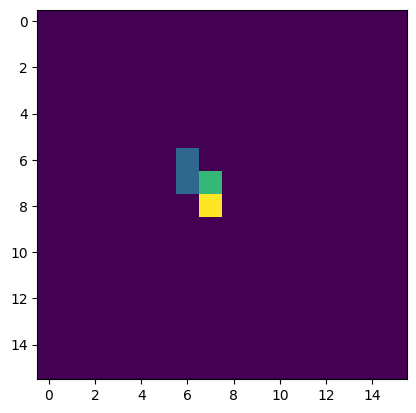

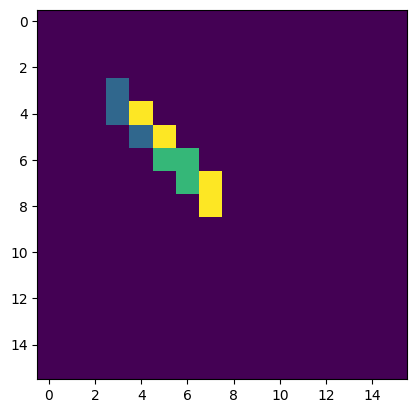

In [11]:
plt.imshow(Q[0, :, :, 0])
plt.show()

plt.imshow(Q[0, :, :, 1])
plt.show()

In [12]:
patch_dim = (1, 1)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)

#patches: 2560000
#unique patches: 4


In [13]:
patch_dim = (4, 4)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)
print("first 5 patches:")

levels = set()
print("Top 10 patches:")
for pat, cnt in patches_ctr.most_common(10):
    print(pat, cnt)
    levels |= set(pat)
print("levels seen in patches:", levels)


#patches: 160000
#unique patches: 9815
first 5 patches:
Top 10 patches:
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 125323
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 690
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 685
(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 648
(1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 644
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0) 491
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3) 490
(0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 455
(3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 455
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2) 422
levels seen in patches: {0, 1, 2, 3}


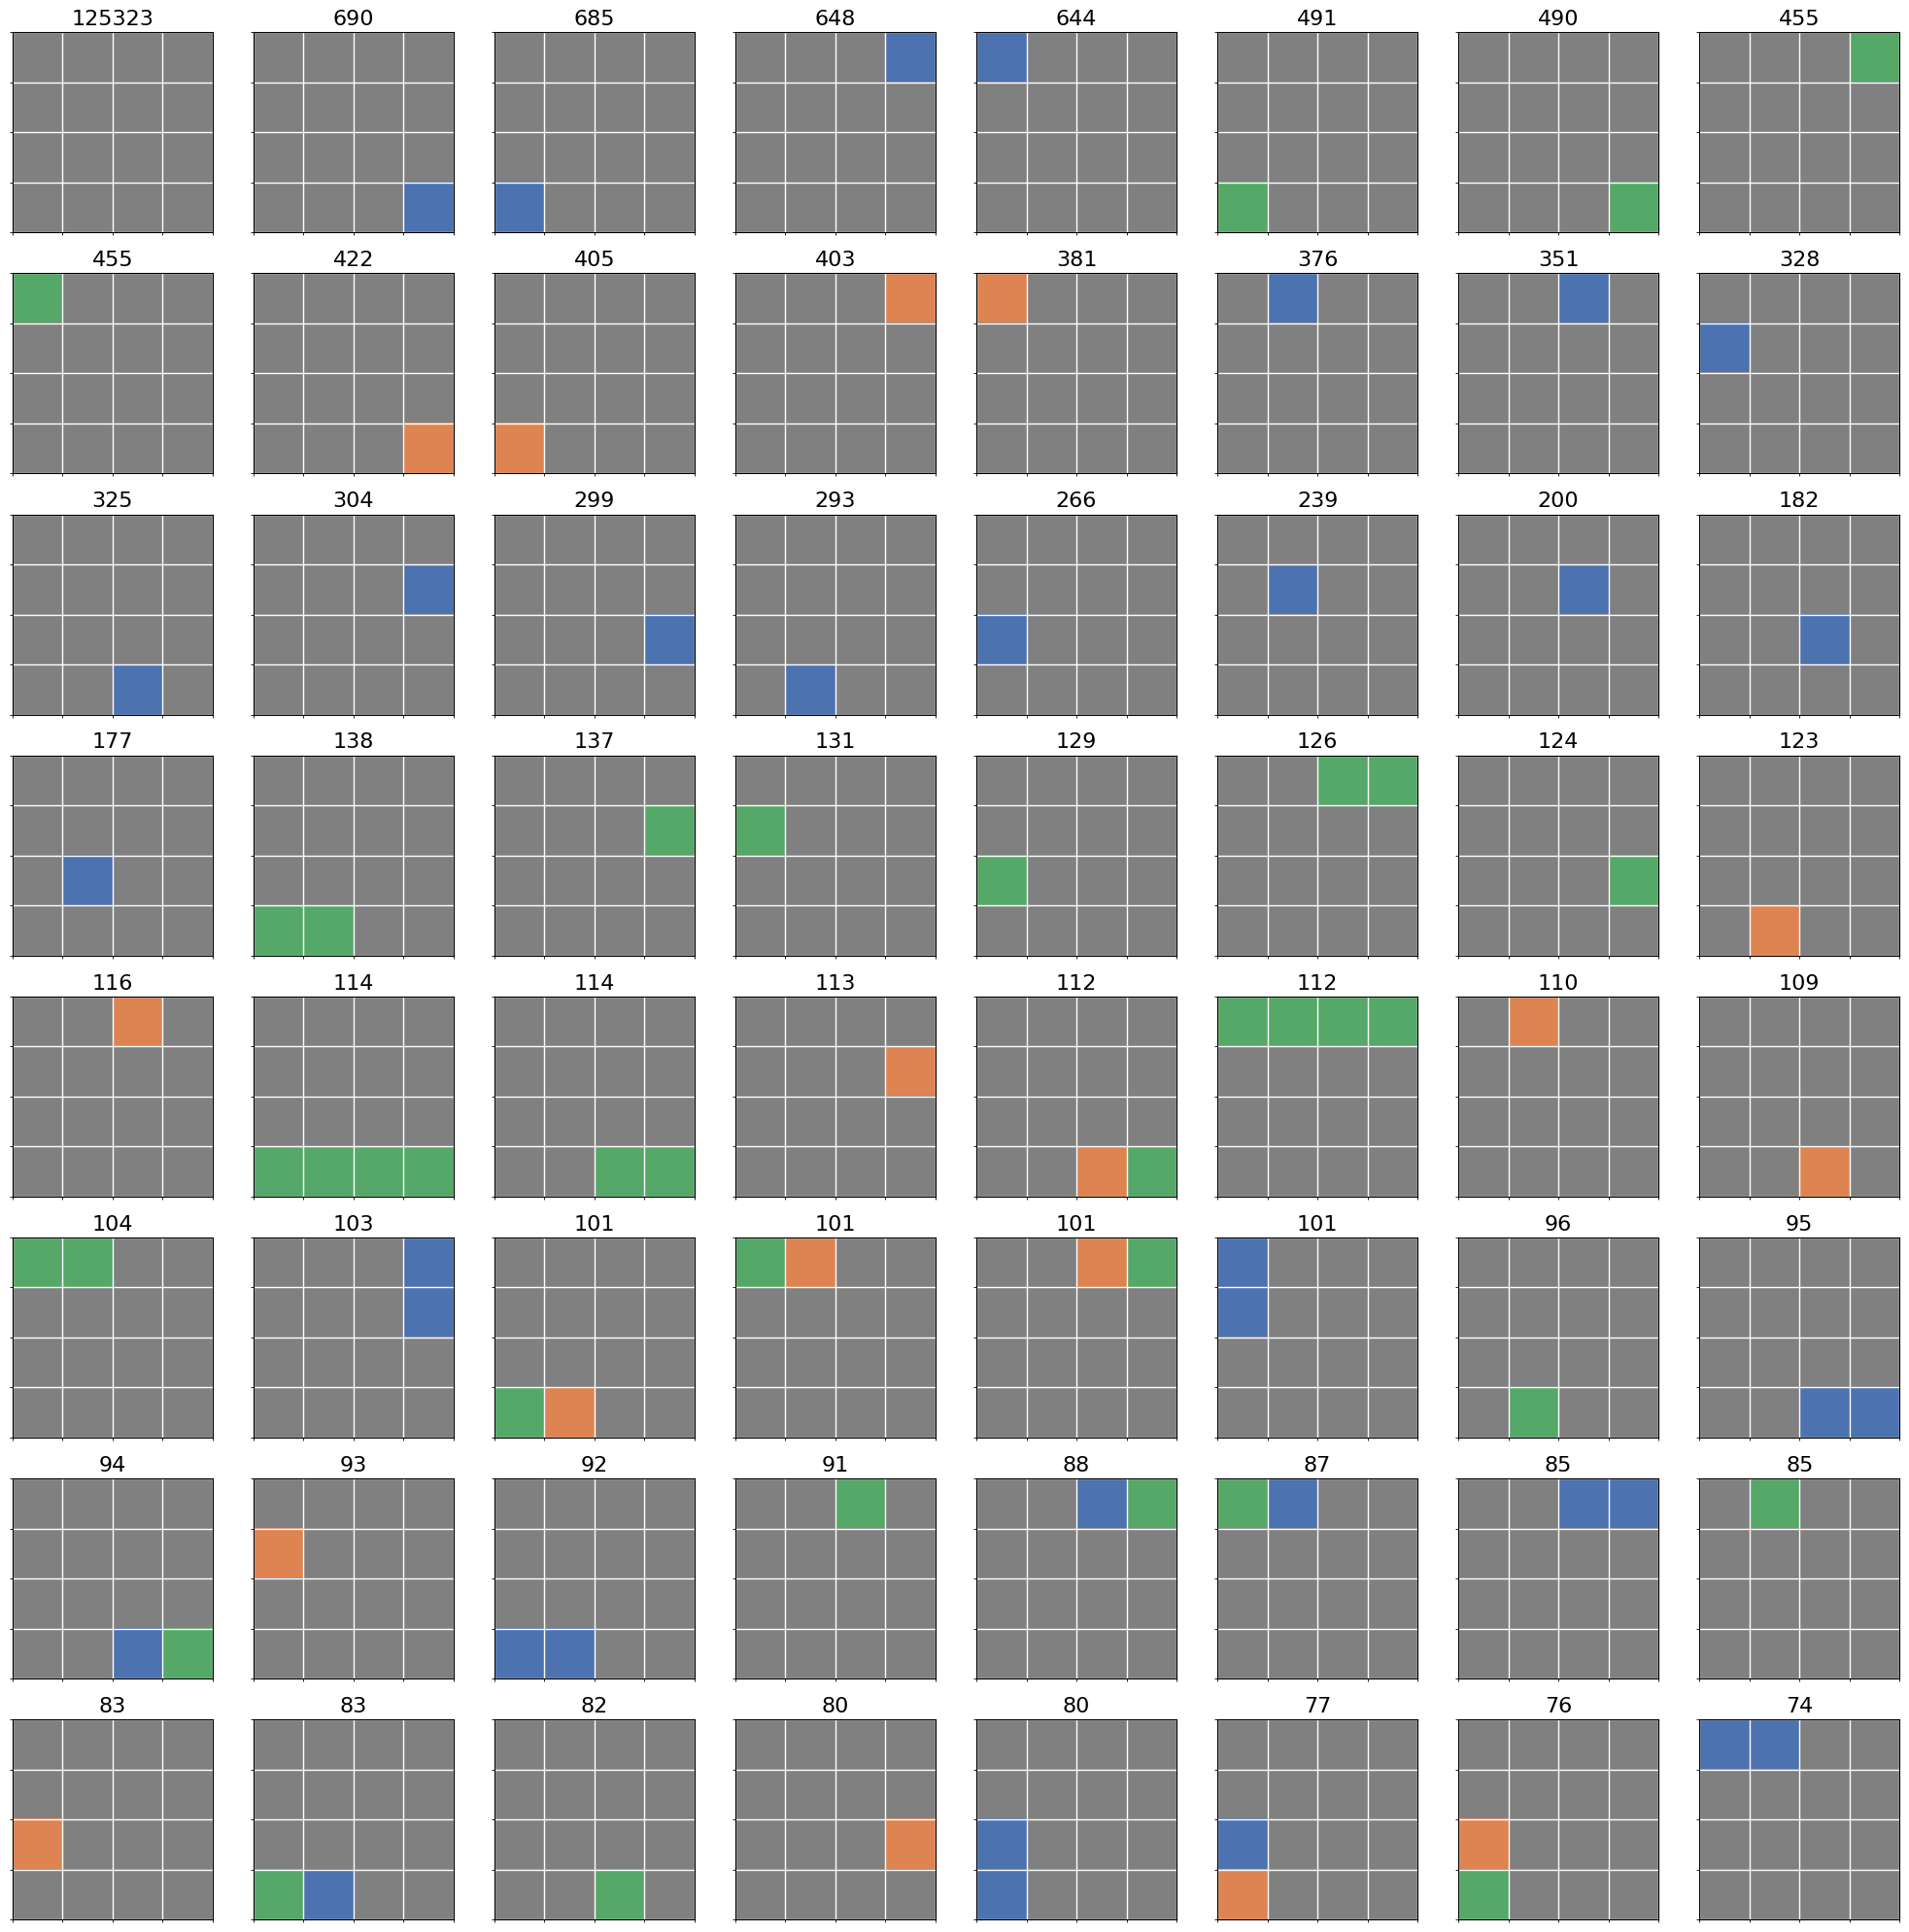

In [14]:
K = 64

from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(8, 8, figsize=(20,20))
cmap = ListedColormap(["grey", "#4C72B0", "#DD8452", "#55A868"])

for ax, (pat, cnt) in zip(axes.flat, patches_ctr.most_common(K)):
    img = np.array(pat).reshape(patch_dim)

    ax.imshow(img, cmap=cmap, vmin=0, vmax=3)

    # ---- draw pixel grid ----
    h, w = img.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

    # ---- clean axes ----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(cnt, fontsize=16)

plt.tight_layout()
plt.show()


In [15]:
def estimate_bits_per_cell_from_topK(patches_ctr, pH, pW, K):
    """
    Simple top-K dictionary + ESC model:
      - encode symbol among (top-K patches + ESC) with ideal entropy H_sym (lower bound)
      - if ESC, transmit raw patch payload (pH*pW*bits_per_entry)

    Returns: (bits_per_cell, p_esc, H_sym_bits_per_patch)
    """
    total = sum(patches_ctr.values())  # total patch *occurrences*
    top = patches_ctr.most_common(K)
    top_counts = np.array([cnt for _, cnt in top], dtype=np.float64)

    levels = set()
    for pat, cnt in top:
        levels |= set(pat)
    n_levels = max(1, len(levels))
    bits_per_entry= np.ceil(np.log2(n_levels))
    
    p_top = top_counts / total
    p_esc = max(0.0, 1.0 - float(p_top.sum()))  # clamp for numerical safety

    # symbol distribution over K+1 symbols (K dictionary entries + ESC)
    p_sym = np.concatenate([p_top, np.array([p_esc])])
    p_nonzero = p_sym[p_sym > 0] # avoid log(0)
    H_sym = -np.sum(p_nonzero * np.log2(p_nonzero))  # bits per patch for symbol (ideal)

    raw_payload_bits = (pH * pW * bits_per_entry)  # sent only on ESC
    bits_per_patch = H_sym + p_esc * raw_payload_bits
    bits_per_cell = bits_per_patch / (pH * pW)

    return bits_per_cell, p_esc, H_sym

In [16]:
patch_dims = [(1,1), (2,2), (3,3), (4,4), (8,8)]
Ks = [8, 16, 32, 64, 128, 256, 512]

rows = []

print(f"{'patch':>9} {'K':>6} {'Keff':>6} {'bits/cell':>10} {'p_esc':>10} {'Hsym(b/patch)':>14} {'#patches':>10} {'#unique':>10}")

for (pH, pW) in patch_dims:
    patches_ctr = extract_patches(Q_int, (pH, pW), stride=None)  # non-overlapping
    npatch = sum(patches_ctr.values())
    nuniq  = len(patches_ctr)

    for K in Ks:
        K_eff = min(K, nuniq) if nuniq > 0 else 0

        bits_cell, p_esc, Hsym = estimate_bits_per_cell_from_topK(
            patches_ctr, pH, pW, K_eff
        )

        print(f"{str((pH,pW)):>9} {K:6d} {K_eff:6d} {bits_cell:10.4f} {p_esc:10.4f} {Hsym:14.4f} {npatch:10d} {nuniq:10d}")

        rows.append((pH, pW, K_eff, bits_cell, p_esc, Hsym, npatch, nuniq))


    patch      K   Keff  bits/cell      p_esc  Hsym(b/patch)   #patches    #unique
   (1, 1)      8      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     16      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     32      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)     64      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    128      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    256      4     0.2973     0.0000         0.2973    2560000          4
   (1, 1)    512      4     0.2973     0.0000         0.2973    2560000          4
   (2, 2)      8      8     0.2675     0.0594         0.5949     640000        256
   (2, 2)     16     16     0.2556     0.0390         0.7102     640000        256
   (2, 2)     32     32     0.2517     0.0263         0.7962     640000        256
   (2, 2)     64     64     0.2483     0.0131         0.8886     640000        256
   (

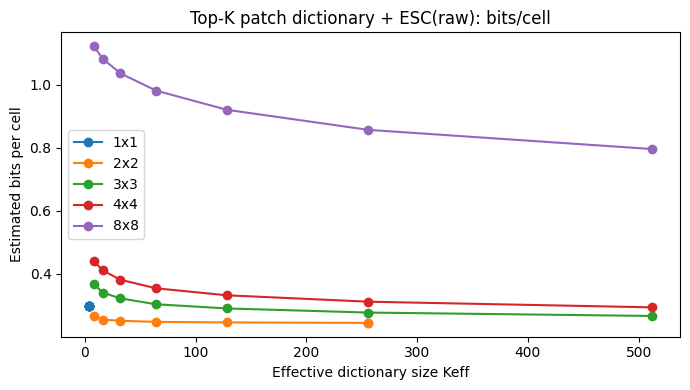

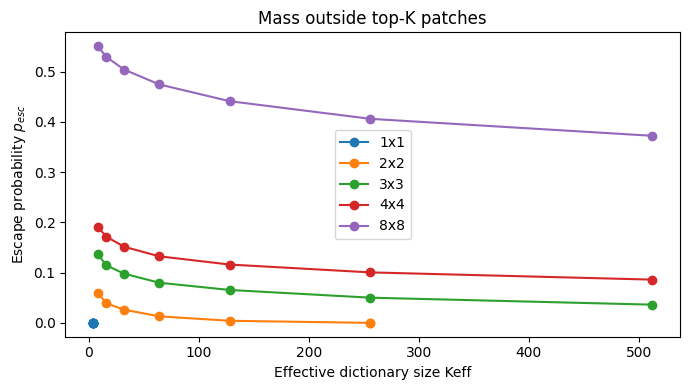

In [17]:
import pandas as pd

df = pd.DataFrame(rows, columns=["pH","pW","Keff","bits_cell","p_esc","Hsym","npatch","nuniq"])
df["patch"] = df["pH"].astype(str) + "x" + df["pW"].astype(str)

# bits/cell vs K (use original Ks on x-axis, but you stored Keff; easiest is plot vs Keff)
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["bits_cell"], marker="o", label=patch)
# plt.xscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Estimated bits per cell")
plt.title("Top-K patch dictionary + ESC(raw): bits/cell")
plt.legend()
plt.tight_layout()
plt.show()

# p_esc vs Keff
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["p_esc"], marker="o", label=patch)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Escape probability $p_{esc}$")
plt.title("Mass outside top-K patches")
plt.legend()
plt.tight_layout()
plt.show()

# Patch ID

In [18]:
from tqdm import tqdm
def extract_gbl_patch_ctr(data_gen, quantizer_model, patch_dim, stride=None, padding=None, max_batches=None):
    """
    Returns global Counter over ALL patches in the dataset (as seen through the generator).
    """
    global_ctr = Counter()
    n_seen = 0
    for (X, _) in tqdm(data_gen, desc="Building Global Patch-CTR"):
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q_tf = quantizer_model(X_tf, training=False)
        Q_int = np.rint(Q_tf.numpy()).astype(np.uint8)

        batch_ctr = extract_patches(Q_int, patch_dim, stride=stride, padding=padding)
        global_ctr += batch_ctr

        n_seen += 1
        if max_batches is not None and n_seen >= int(max_batches):
            break

    return global_ctr

In [19]:
patch_dim = (3, 4)
unk_id=0
patches_ctr = extract_gbl_patch_ctr(
    training_generator, 
    quantizer_model,
    patch_dim=patch_dim,
    stride=None,
    padding="same",
    max_batches=None      # set e.g. 1 for a quick approximation
)

Building Global Patch-CTR: 100%|██████████| 84/84 [00:43<00:00,  1.95it/s]


unique patterns used: 70775
total patch occurrences: 20005104
min/max count: 1 16824513


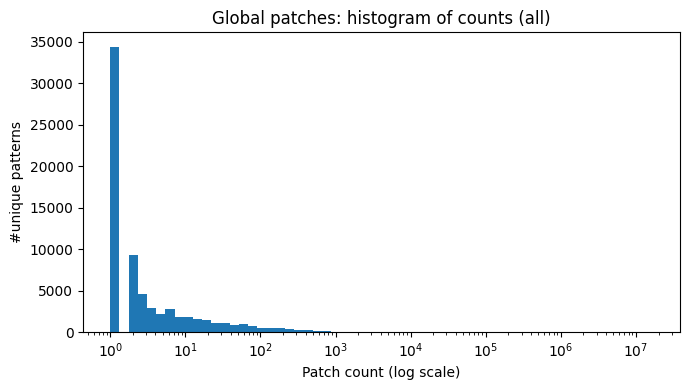

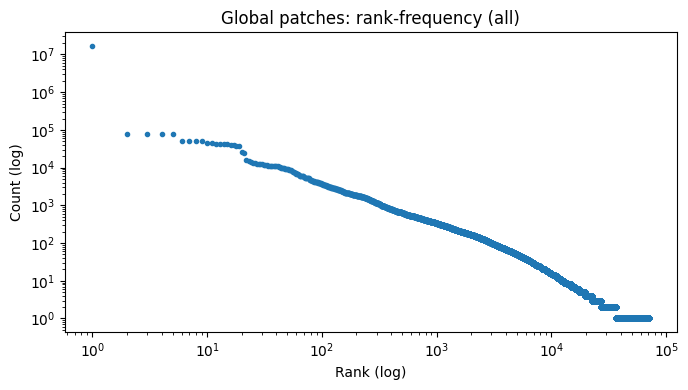

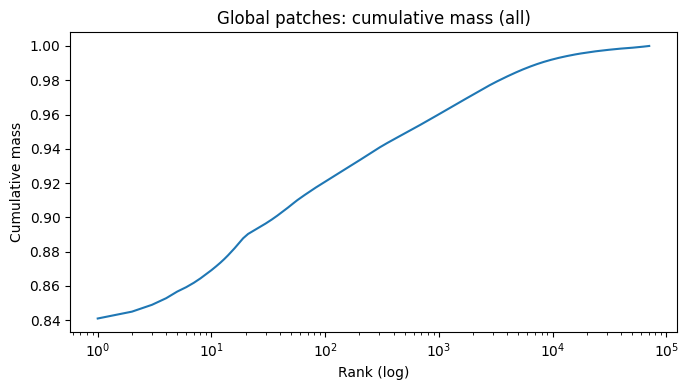

unique patterns used: 512
total patch occurrences: 18991563
min/max count: 620 16824513


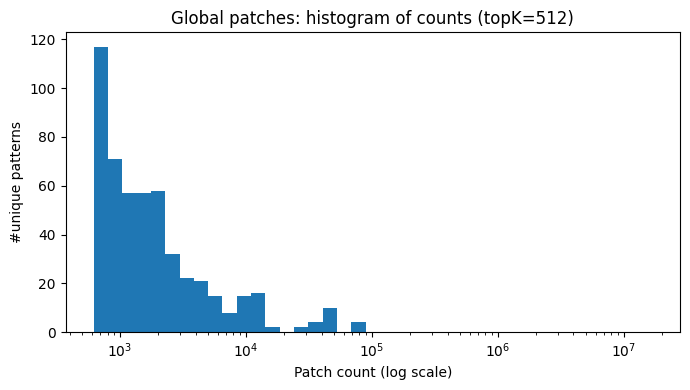

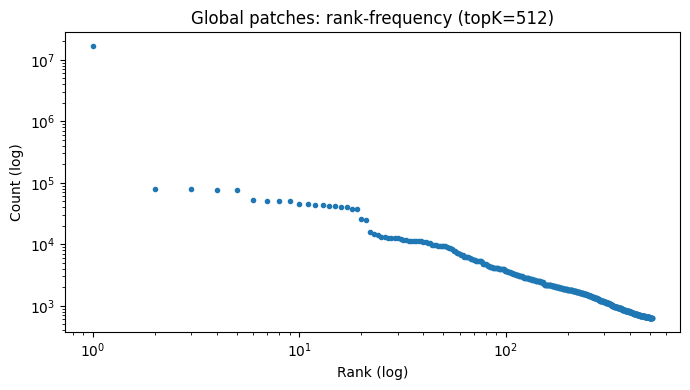

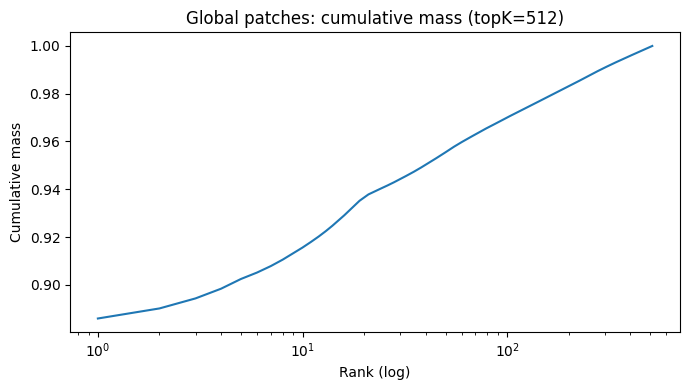

In [51]:
def plot_patch_counter_hist(patches_ctr, topK=None, logx=True, nbins=50, title_prefix="Patch counter"):
    """
    patches_ctr: Counter {patch_tuple: count}
    topK: if set, only use top-K patterns for plots
    """
    items = patches_ctr.most_common(topK) if topK is not None else list(patches_ctr.items())
    cnts = np.array([c for _, c in items], dtype=np.int64)

    total = cnts.sum()
    print("unique patterns used:", len(cnts))
    print("total patch occurrences:", int(total))
    print("min/max count:", int(cnts.min()), int(cnts.max()))

    # 1) Histogram of counts
    plt.figure(figsize=(7,4))
    if logx:
        bins = np.logspace(np.log10(max(1, cnts.min())), np.log10(cnts.max()), nbins)
        plt.hist(cnts, bins=bins)
        plt.xscale("log")
        plt.xlabel("Patch count (log scale)")
    else:
        plt.hist(cnts, bins=nbins)
        plt.xlabel("Patch count")

    plt.ylabel("#unique patterns")
    plt.title(f"{title_prefix}: histogram of counts" + (f" (topK={topK})" if topK else " (all)"))
    plt.tight_layout()
    plt.show()

    # 2) Rank-frequency (Zipf-style)
    plt.figure(figsize=(7,4))
    cnts_sorted = np.sort(cnts)[::-1]
    ranks = np.arange(1, len(cnts_sorted)+1)
    plt.plot(ranks, cnts_sorted, marker=".", linestyle="none")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Rank (log)")
    plt.ylabel("Count (log)")
    plt.title(f"{title_prefix}: rank-frequency" + (f" (topK={topK})" if topK else " (all)"))
    plt.tight_layout()
    plt.show()

    # 3) Cumulative probability mass vs rank
    plt.figure(figsize=(7,4))
    p = cnts_sorted / cnts_sorted.sum()
    cum = np.cumsum(p)
    plt.plot(ranks, cum)
    plt.xscale("log")
    plt.xlabel("Rank (log)")
    plt.ylabel("Cumulative mass")
    plt.title(f"{title_prefix}: cumulative mass" + (f" (topK={topK})" if topK else " (all)"))
    plt.tight_layout()
    plt.show()

# Example usage after you build patches_ctr:
plot_patch_counter_hist(patches_ctr, topK=None, logx=True, nbins=60, title_prefix="Global patches")
# or just top-K:
plot_patch_counter_hist(patches_ctr, topK=512, logx=True, nbins=40, title_prefix="Global patches")

In [20]:
def build_patch_dict_from_counter(patches_ctr, K, unk_id=0):
    """
    patch2id maps top-K patches to IDs 1..K. 0 reserved for UNK.
    """
    patch2id = {}
    K_eff = min(int(K), len(patches_ctr))  # guard if K > #unique
    for i, (pat, _) in enumerate(patches_ctr.most_common(K_eff), start=1):
        patch2id[pat] = i
    return patch2id, unk_id

In [21]:
K = 511
patch2id, unk_id = build_patch_dict_from_counter(patches_ctr, K, unk_id)
vocab_size = K + 1
print(patch2id)
print(unk_id)
print(vocab_size)

{(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 1, (0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0): 2, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1): 3, (0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0): 4, (1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 5, (0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0): 6, (3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 7, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3): 8, (0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0): 9, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2): 10, (0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0): 11, (0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0): 12, (2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 13, (0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0): 14, (0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0): 15, (0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0): 16, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0): 17, (0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0): 18, (0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0): 19, (0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0): 20, (0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0): 21, (0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3): 22, (0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0): 23, (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0): 24, 

In [22]:
def build_patch_LUT(patch2id, patch_dim, *, unk_id=0):
    """
    Returns tf.lookup.StaticHashTable mapping base-4 encoded patch key -> token id.

    base-4 key: key = sum_{j=0..K-1} patch[j] * 4^j   (K = pH*pW)
    """
    pH, pW = patch_dim
    K = pH * pW
    pow4 = (4 ** np.arange(K, dtype=np.int64))

    # keys for table
    keys_np = np.array(
        [np.dot(np.asarray(pat, dtype=np.int64), pow4) for pat in patch2id.keys()],
        dtype=np.int64
    )
    vals_np = np.array(list(patch2id.values()), dtype=np.int64)

    init = tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(keys_np, dtype=tf.int64),
        values=tf.constant(vals_np, dtype=tf.int64),
        key_dtype=tf.int64,
        value_dtype=tf.int64,
    )
    table = tf.lookup.StaticHashTable(init, default_value=tf.constant(unk_id, tf.int64))
    return table

patch_LUT = build_patch_LUT(patch2id, patch_dim, unk_id=unk_id)

In [43]:
def tokenize_batch(Q_int, patch_dim, patch_LUT, stride=None, padding=None, *, unk_id=0, return_coords=False):
    pH, pW = patch_dim
    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride

    Q = tf.convert_to_tensor(Q_int)
    B = tf.shape(Q)[0]
    H = tf.shape(Q)[1]
    W = tf.shape(Q)[2]
    C = tf.shape(Q)[3]

    # (B,H,W,C) -> (B,C,H,W,1) -> (B*C,H,W,1)
    Q_bc = tf.transpose(Q, [0, 3, 1, 2])
    Q_bc = tf.reshape(Q_bc, [-1, H, W, 1])

    padding_tf = "VALID" if padding is None else str(padding).upper()

    patches = tf.image.extract_patches(
        images=Q_bc,
        sizes=[1, pH, pW, 1],
        strides=[1, dY, dX, 1],
        rates=[1, 1, 1, 1],
        padding=padding_tf,
    )  # (B*C, out_h, out_w, K)

    K = pH * pW
    powv = tf.pow(tf.constant(4, tf.int64), tf.range(K, dtype=tf.int64))  # (K,)
    keys = tf.reduce_sum(tf.cast(patches, tf.int64) * powv, axis=-1)      # (B*C, out_h, out_w)

    ids = patch_LUT.lookup(keys)  # int64
    out_h = tf.shape(ids)[1]
    out_w = tf.shape(ids)[2]

    ids = tf.reshape(ids, [B, C, out_h, out_w])      # (B,C,oy,ox)
    tokens = tf.reshape(ids, [B, C * out_h * out_w]) # (B,L)
    tokens = tf.cast(tokens, tf.int32)

    if not return_coords:
        return tokens

    if padding_tf == "VALID":
        y0 = tf.range(out_h, dtype=tf.int32) * dY
        x0 = tf.range(out_w, dtype=tf.int32) * dX
    else:
        # SAME padding convention: out = ceil(in/stride)
        out_h_same = (H + dY - 1) // dY
        out_w_same = (W + dX - 1) // dX

        padY = tf.maximum((out_h_same - 1) * dY + pH - H, 0)
        padX = tf.maximum((out_w_same - 1) * dX + pW - W, 0)
        pad_top  = padY // 2
        pad_left = padX // 2

        y0 = tf.range(out_h, dtype=tf.int32) * dY - pad_top
        x0 = tf.range(out_w, dtype=tf.int32) * dX - pad_left

    yy, xx = tf.meshgrid(y0, x0, indexing="ij")  # (oy,ox)
    yx = tf.stack([tf.reshape(yy, [-1]), tf.reshape(xx, [-1])], axis=1)  # (oy*ox,2)

    Lsp = tf.shape(yx)[0]
    ccol = tf.repeat(tf.range(C), Lsp)
    yx_rep = tf.tile(yx, [C, 1])
    coords = tf.concat([tf.expand_dims(ccol, 1), yx_rep], axis=1)  # (L,3) = (c,y,x)

    return tokens, coords

In [44]:
class TokenizedSequence(keras.utils.Sequence):
    def __init__(self, base_seq, quantizer_model, patch_dim, patch_LUT, unk_id=0, stride=None, padding=None):
        self.base = base_seq
        self.qm = quantizer_model
        self.patch_dim = patch_dim
        self.patch_LUT = patch_LUT
        self.unk_id = unk_id
        self.stride = stride
        self.padding = padding

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        X, y = self.base[idx]  # X: (B,H,W,C) float32, y: (B,4) (numpy)

        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q_tf = self.qm(X_tf, training=False)
        Q_int = tf.cast(tf.round(Q_tf), tf.int64)

        tokens = tokenize_batch(
            Q_int,                      
            self.patch_dim,
            self.patch_LUT,           
            stride=self.stride,
            padding=self.padding,
            unk_id=self.unk_id
        )

        return tokens, y

In [45]:
train_tok = TokenizedSequence(training_generator, quantizer_model, patch_dim, patch_LUT, 
                              unk_id=unk_id, stride=None, padding = "same")
val_tok   = TokenizedSequence(validation_generator, quantizer_model, patch_dim, patch_LUT, 
                              unk_id=unk_id, stride=None, padding = "same")

t0, y0 = train_tok[0]
print("seq_len:", seq_len)
print("tokens:", t0.shape, t0.dtype, "y:", y0.shape, y0.dtype)

# seq_len from tokens
seq_len = t0.shape[1]
print("seq_len:", seq_len)

seq_len: 48
tokens: (5000, 48) <dtype: 'int32'> y: (5000, 4) <dtype: 'float32'>
seq_len: 48


In [46]:
def create_LUT_model(seq_len, vocab_size, d_model=64, n_heads=8, ff=128, n_layers=6, n_outputs=14):
    tokens_in = tf.keras.layers.Input(shape=(seq_len,), dtype=tf.int32, name="patch_ids")
    tok_emb = tf.keras.layers.Embedding(vocab_size, d_model, name="tok_emb")(tokens_in)

    pos_ids = tf.range(seq_len)[None, :]
    pos_emb = tf.keras.layers.Embedding(seq_len, d_model, name="pos_emb")(pos_ids)
    x = tok_emb + pos_emb

    for i in range(n_layers):
        # Self-attn block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads)(x, x)
        x = tf.keras.layers.Add()([x0, x])

        # FFN block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.Dense(ff, activation="gelu")(x)
        x = tf.keras.layers.Dense(d_model)(x)
        x = tf.keras.layers.Add()([x0, x])

    x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # Head
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)

    out = tf.keras.layers.Dense(n_outputs, name="head")(x)

    return tf.keras.Model(tokens_in, out)

lut_model = create_LUT_model(seq_len=seq_len, vocab_size=vocab_size, n_outputs=14)

lut_model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

lut_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patch_ids           │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tok_emb (Embedding) │ (None, 48, 64)    │     32,768 │ patch_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 48, 64)    │          0 │ tok_emb[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 48, 64)    │          0 │ add_13[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 48, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 48, 64)    │      8,256 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 48, 64)    │          0 │ add_14[0][0],     │
│                     │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 48, 64)    │          0 │ add_15[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 48, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 48, 64)    │      8,256 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 48, 64)    │          0 │ add_16[0][0],     │
│                     │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 48, 64)    │     16,640 │ layer_normalizat

 Total params: 251,278 (981.55 KB)

 Trainable params: 251,278 (981.55 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_LUT_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, "weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5")

In [48]:
# 9f5e5c2c : 1000 epochs
print(checkpoint_filepath)
print(fingerprint)

./trained_LUT_models/model-df706c2a-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5
df706c2a


In [49]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [50]:
history = lut_model.fit(
    train_tok,
    validation_data=val_tok,
    callbacks=[mcp, csv_logger, es],
    epochs=1000,
    verbose=1
)

Epoch 1/1000


2026-01-09 05:41:18.968683: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 16 bytes spill stores, 16 bytes spill loads

2026-01-09 05:41:19.323656: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 308 bytes spill stores, 276 bytes spill loads

2026-01-09 05:41:28.947549: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_19', 112 bytes spill stores, 112 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_18', 88 bytes spill stores, 88 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_17', 176 bytes spill stores, 148 bytes spill

 2/84 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 103616.3281  

2026-01-09 05:41:35.210180: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 16 bytes spill stores, 16 bytes spill loads

2026-01-09 05:41:35.623914: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 308 bytes spill stores, 276 bytes spill loads

2026-01-09 05:41:45.466084: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_18', 112 bytes spill stores, 112 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_17', 368 bytes spill stores, 368 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_16', 176 bytes spill stores, 148 bytes spi

 9/84 ━━━━━━━━━━━━━━━━━━━━ 2:42 2s/step - loss: 100205.8516

...

2026-01-09 05:42:50.745282: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 16 bytes spill stores, 16 bytes spill loads

2026-01-09 05:42:50.942586: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 308 bytes spill stores, 276 bytes spill loads



82/84 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 102454.2109   

2026-01-09 05:43:06.561427: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 16 bytes spill stores, 16 bytes spill loads

2026-01-09 05:43:07.096994: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_57', 308 bytes spill stores, 276 bytes spill loads



84/84 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 102474.5859 - val_loss: 103006.6328
Epoch 2/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - loss: 103355.6562 - val_loss: 103006.6328
Epoch 3/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 210ms/step - loss: 103143.6641 - val_loss: 103006.6328
Epoch 4/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - loss: 102841.6328 - val_loss: 103006.6328
Epoch 5/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - loss: 101752.2422 - val_loss: 103006.6328
Epoch 6/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 215ms/step - loss: 102781.3906 - val_loss: 103006.6328
Epoch 7/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - loss: 103313.6172 - val_loss: 103006.6328
Epoch 8/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - loss: 102977.9688 - val_loss: 103006.6328
Epoch 9/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - loss: 103107.5469 - val_loss: 103006.6328
Epoch 10/1000
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - loss: 103175.0781 - val_loss: 103006.6328
Epoch 11/1000
84/84 ━━━━

KeyboardInterrupt: 